# Sudbury Dike Swarm ca. 1235 Ma paleomagnetic pole

## Geologic context

The Sudbury dikes are northwest-trending alkali olivine diabase dikes that
intrude the Southern Structural Province of the Canadian Shield around Sudbury,
Ontario, and can be traced across the Grenville Front into the Grenville Province
(Palmer, Merz & Hayatsu, 1977). Away from the front, in the Southern Province,
the dikes carry a westerly directed, shallow primary magnetization (the "Sudbury
dike direction"). Within 2-8 km northwest of the Grenville Front the same dikes
are remagnetized to an east-southeast and downward direction (the "Grenville
Front direction") associated with anomalously high apparent K-Ar ages, recording
a ca. 1000 Ma Grenvillian thermal overprint. The primary remanence is shown to be
a primary cooling remanence by baked-contact tests (site 90 against Gowganda
Formation argillites; Sopher, 1963; Schwarz, 1977).

The dikes are dated by U-Pb baddeleyite at 1238 ± 4 Ma (Krogh et al., 1987), superseding the paper's ca. 1250 Ma K-Ar estimate.

## Paleomagnetic And Rock Magnetic Data

This notebook recreates the primary Sudbury Dike Swarm pole at the site level
from the 38 dikes carrying the Sudbury dike direction, computes the
paleosecular-variation diagnostics, and documents the positive baked-contact
test. The Grenville-Front overprint direction is shown for context.

## Age Constraints

- Curent age bracket: nominal age 1238 Ma, lomagage 1234 Ma, himagage 1242 Ma.
- Proposed new bracket: nominal age 1235 Ma, lomagage 1242 Ma, himagage 1232 Ma.
- Preivously cited a U-Pb baddeleyite at 1238 ± 4 Ma by Krogh et al., 1987; but there is a Dudàs et al., 1994 paper that dated U-Pb baddeleyite ID-TIMS from four dikes and a combined baddeleyite concordia upper intercept age of 1235 +7/-3 Ma is reported. That study also dated two zircons but the zircons are much more discordant than the almost concordiant baddeleyite analyses. We prefer to use the baddeleyite only regression age as the age constraint for the paleomagnetic pole, and update the age assignmnts. 

## References

- Paleomagnetic source: 
- Geochronology / age-constraint note (compilation): Krogh, T., Corfu, F., Davis, D., Dunning, G., Heaman, L., Kamo, S., Machado, N., Greenough, J., & Nakamura, E. (1987). Precise U–Pb isotopic ages of diabase dykes and mafic to ultramafic rocks using trace amounts of baddeleyite and zircon. Mafic Dyke Swarms. Edited by HC Halls and WF Fahrig. Geological Association of Canada, Special Paper, 34, 147–152.
- Dudàs, F. O., Davidson, A., & Bethune, K. M. (1994). Age of the Sudbury diabase dykes and their metamorphism in the Grenville Province, Ontario (Nos. 1994-F; pp. 1994-F). https://doi.org/10.4095/195175

In [1]:
import pole_tools as pt
import pmagpy.ipmag as ipmag
import pmagpy.pmag as pmag
import matplotlib.pyplot as plt

%config InlineBackend.figure_format='retina'
%matplotlib inline

## Site-level data

Site means are loaded from the MagIC contribution in
`../data/1237_Sudbury/` (assembled in `contribution_build/` from the audited
Palmer et al. (1977) contribution). The dikes are vertical and the directions are
in-situ (`dir_tilt_correction == 0`). The primary pole uses the 38 sites carrying
the `Sudbury Dike direction`; the 26 `Grenville Front direction` sites record the
younger overprint.

In [2]:
sites_geo, _ = pt.load_magic_sites('../data/1237_Sudbury/sites.txt')
print(sites_geo['dir_comp_name'].value_counts())

sudbury = sites_geo[sites_geo['dir_comp_name'] == 'Sudbury Dike direction'].reset_index(drop=True)
grenville = sites_geo[sites_geo['dir_comp_name'] == 'Grenville Front direction'].reset_index(drop=True)
study_lat, study_lon = 46.3, 278.6
print(f'\n{len(sudbury)} Sudbury-dike-direction sites; {len(grenville)} Grenville-Front-overprint sites')
sudbury[['site', 'lat', 'lon', 'dir_dec', 'dir_inc', 'dir_k', 'dir_alpha95',
         'dir_n_samples', 'vgp_lat', 'vgp_lon']].head(10)

Sudbury Dike direction       38
Grenville Front direction    26
Name: dir_comp_name, dtype: int64

38 Sudbury-dike-direction sites; 26 Grenville-Front-overprint sites


,site,lat,lon,dir_dec,dir_inc,dir_k,dir_alpha95,dir_n_samples,vgp_lat,vgp_lon
0,1,46.39,277.24,274,-2,499,4,4,2,185
1,2,46.36,277.27,271,-15,529,4,4,-5,183
2,3,46.40,277.27,274,7,843,3,4,5,188
3,5,46.42,277.35,270,-4,76,29,2,-1,187
4,6,46.30,277.72,272,7,129,8,4,4,189
5,8,46.25,277.73,261,8,3487,2,4,-3,197
6,9,46.24,277.60,263,0,1582,2,4,-5,193
7,21,46.20,277.51,277,-4,77,11,4,3,182
8,22,46.18,277.48,258,-11,924,3,4,-12,193
9,28,46.14,277.62,243,16,90,10,4,-12,214


## Mean pole from site VGPs

The Sudbury dike direction is westerly and shallow, so the VGPs form a single
coherent (near-equatorial) cluster; the Fisher mean is taken without polarity
flipping to preserve the published southern-hemisphere pole convention.

Plon: 193.1  Plat: -2.9
Number of directions in mean (n): 38
Angular radius of 95% confidence (A_95): 3.3
Precision parameter (k) estimate: 50.4

Palmer et al. (1977) pole: 168 W / 2.5 S (= -2.5 N, 192 E), A95 2.5, N=38
prior Nordic compilation (combined, GPMDB 2175): -2.5 N / 192.8 E, A95 2.5


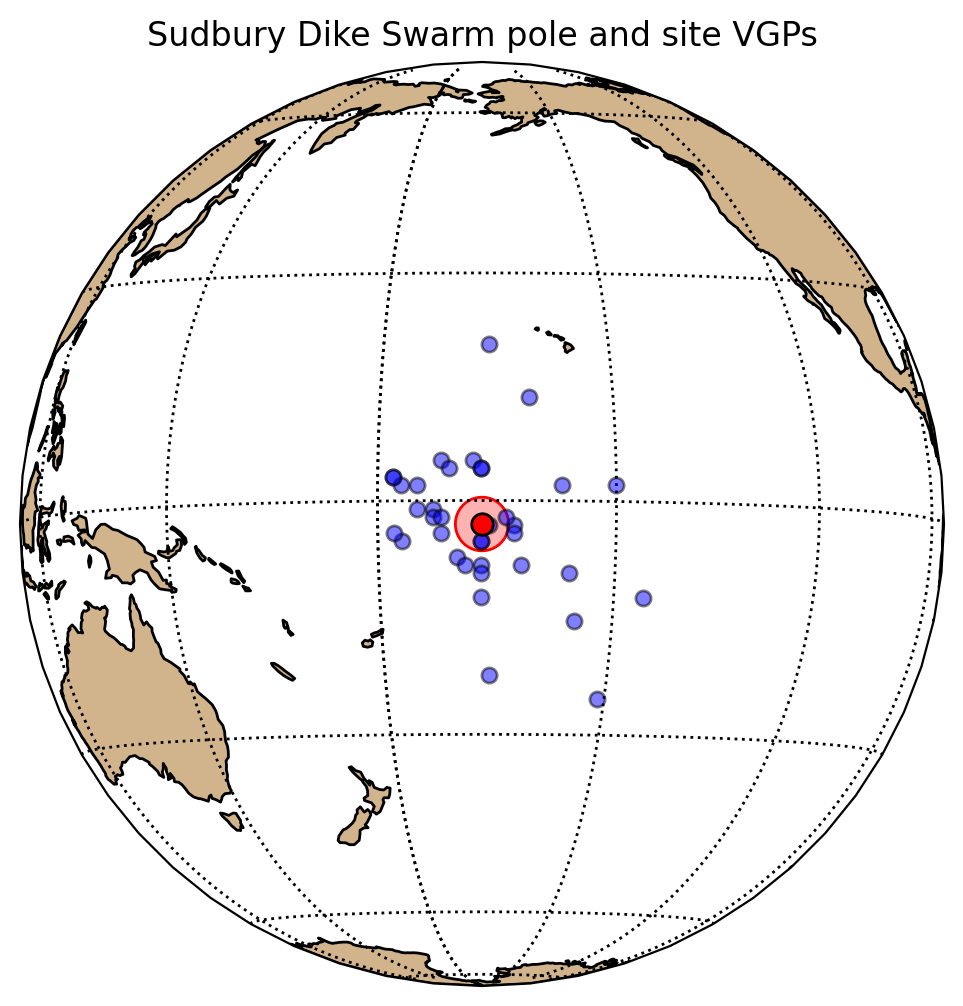

In [3]:
vgp_block, pole_mean = pt.compute_mean_pole(sudbury, unify_polarity=False)
ipmag.print_pole_mean(pole_mean)
print('\nPalmer et al. (1977) pole: 168 W / 2.5 S (= -2.5 N, 192 E), A95 2.5, N=38')
print('prior Nordic compilation (combined, GPMDB 2175): -2.5 N / 192.8 E, A95 2.5')

_ = pt.plot_vgps_and_pole(vgp_block, pole_mean, central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'], figsize=(6, 6))
plt.title('Sudbury Dike Swarm pole and site VGPs')
plt.show()

## Mean direction (in-situ)

Dec: 264.8  Inc: 1.7
Number of directions in mean (n): 38
Angular radius of 95% confidence (a_95): 4.5
Precision parameter (k) estimate: 27.5


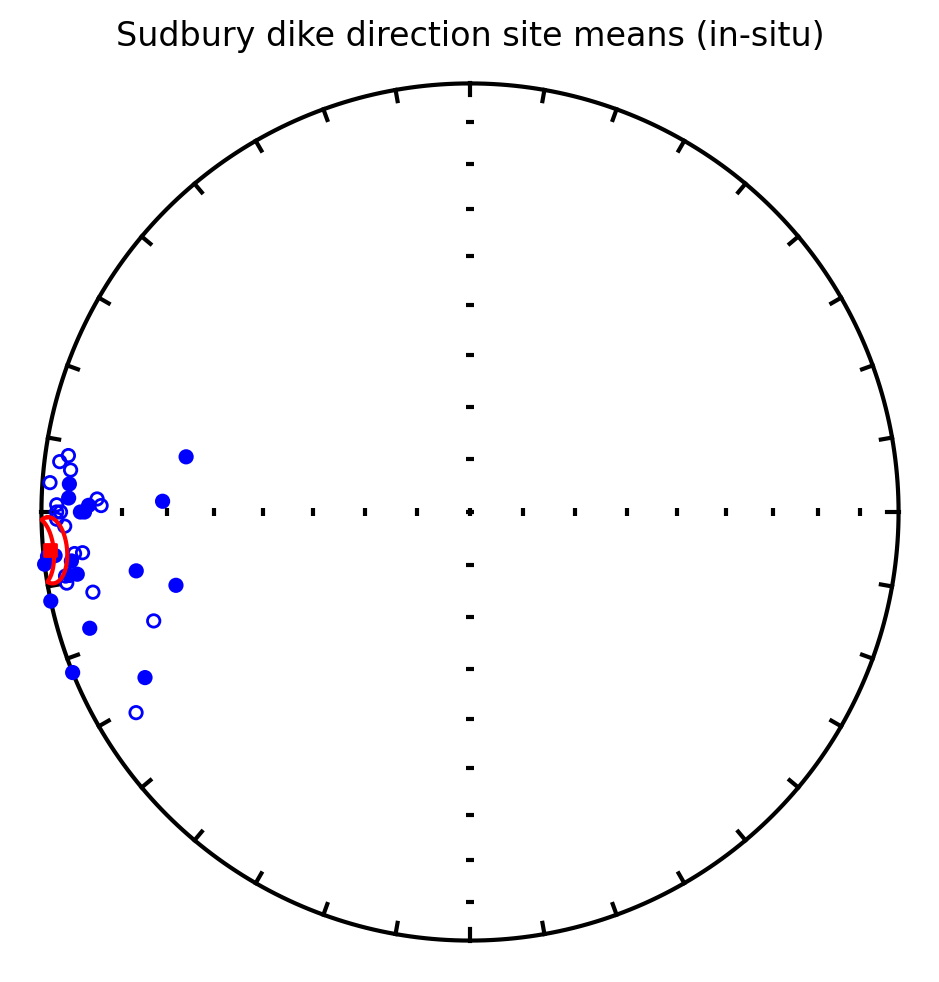

In [4]:
dir_block, dir_mean = pt.compute_mean_direction(sudbury, unify_polarity=False)
ipmag.print_direction_mean(dir_mean)
ipmag.plot_net()
ipmag.plot_di(di_block=dir_block, color='blue', marker='o')
ipmag.plot_di_mean(dir_mean['dec'], dir_mean['inc'], dir_mean['alpha95'],
                   color='red', marker='s')
plt.title('Sudbury dike direction site means (in-situ)')
plt.show()

## Field test: baked contacts and the Grenville-Front overprint

Palmer et al. (1977) demonstrated the primary origin of the Sudbury dike
magnetization with a positive baked-contact test at site 90, where a dike with
the Sudbury dike direction bakes Gowganda Formation argillites whose
characteristic remanence is steeply down (the regional Grenville remanence),
together with the earlier positive baked-contact tests of Sopher (1963) and
Schwarz (1977) against Sudbury norite. Approaching the Grenville Front, the dikes
are remagnetized to the east-southeast-and-down Grenville Front direction. The
two directional populations are plotted below.

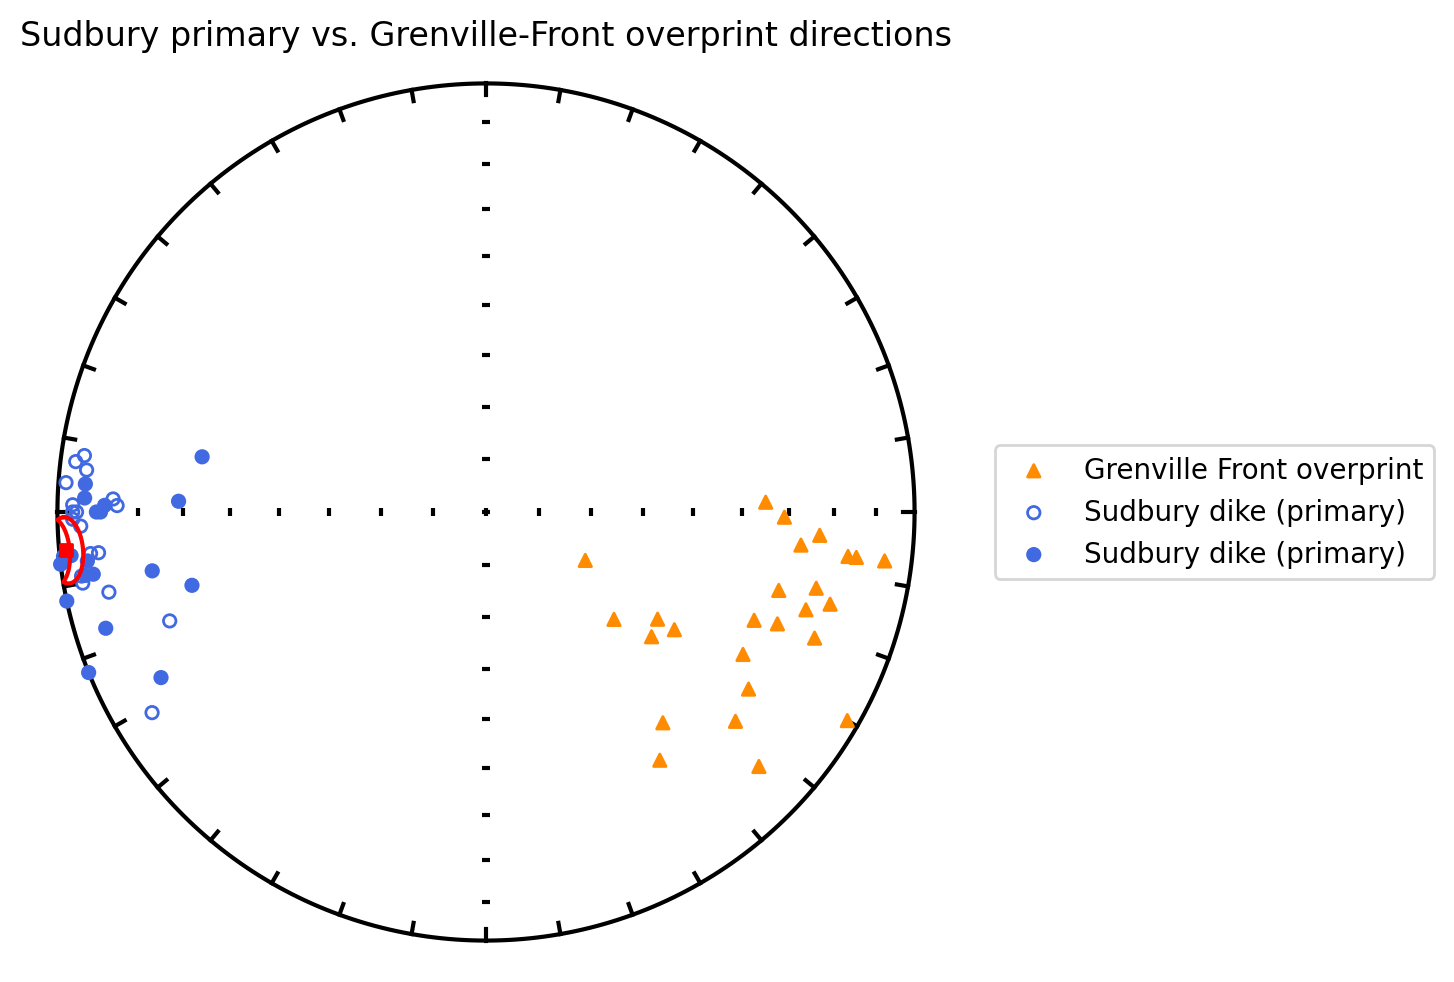

In [5]:
ipmag.plot_net()
ipmag.plot_di(grenville['dir_dec'].tolist(), grenville['dir_inc'].tolist(),
              color='darkorange', marker='^', label='Grenville Front overprint')
ipmag.plot_di(sudbury['dir_dec'].tolist(), sudbury['dir_inc'].tolist(),
              color='royalblue', marker='o', label='Sudbury dike (primary)')
ipmag.plot_di_mean(dir_mean['dec'], dir_mean['inc'], dir_mean['alpha95'],
                   color='red', marker='s')
plt.legend(loc='center left', bbox_to_anchor=(1.05, 0.5))
plt.title('Sudbury primary vs. Grenville-Front overprint directions')
plt.show()

## Paleosecular variation and VGP-shape diagnostics

A_95 of 3.3 passes Deenen et al. (2011) criteria of being between 2.8 and 8.3 for this number of sites


<AxesSubplot:title={'center':'Deenen et al. (2011) test'}, xlabel='Number of sites (N)', ylabel='$A_{95}$ (°)'>

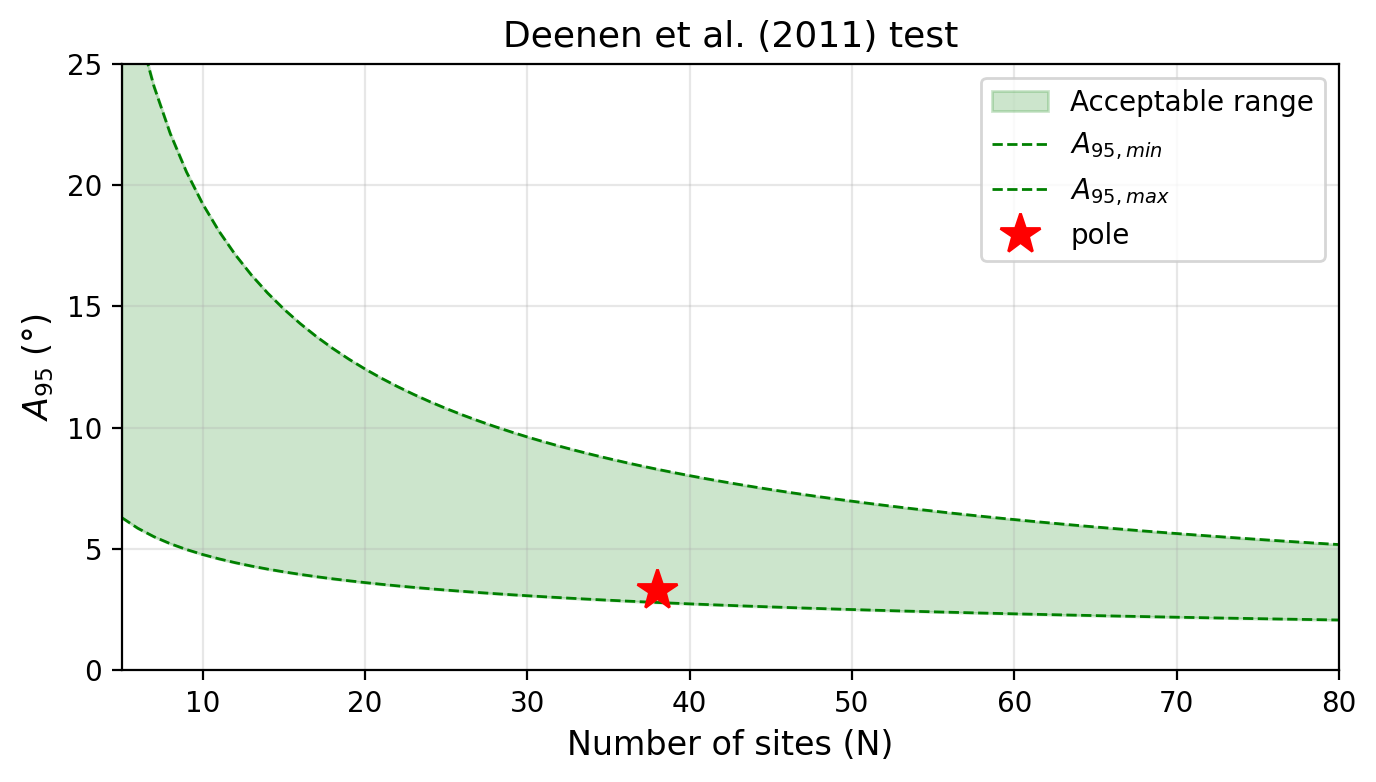

In [6]:
pt.Deenen_test(pole_mean['n'], pole_mean['alpha95'])
pt.plot_Deenen_test(pole_mean)

{'Mode': 'Mode 2',
 'Dec': -167.03313082411694,
 'Inc': -2.8757947605469294,
 'N': 38,
 'Mu': 0.9922754266662076,
 'Mu_critical': 1.207,
 'Me': 0.77947285444213,
 'Me_critical': 1.094,
 'Test_result': 'Consistent with Fisher distribution'}

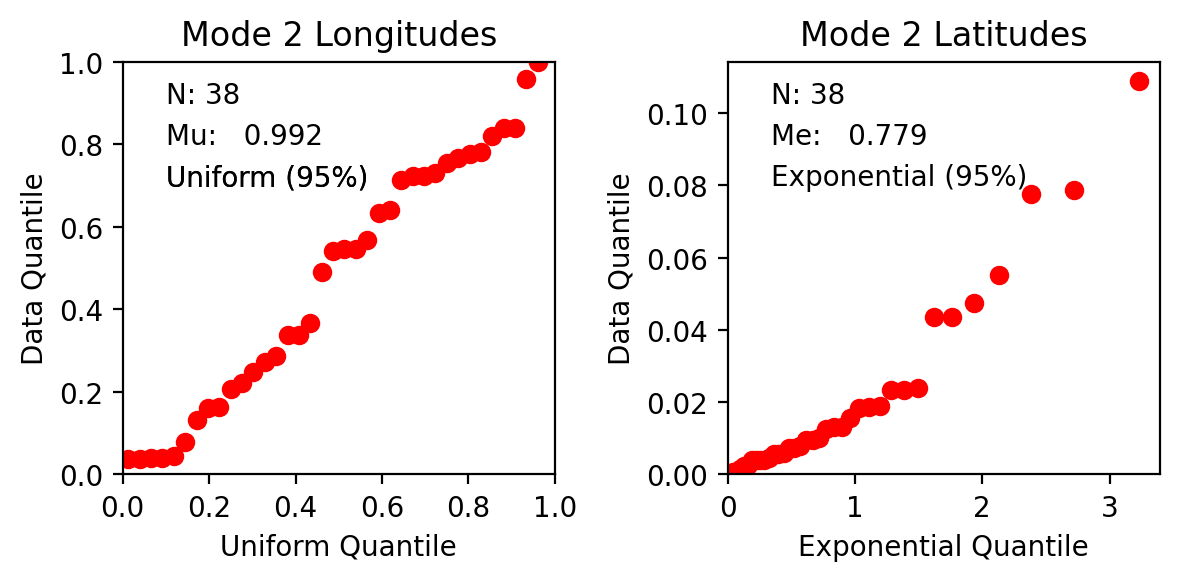

In [7]:
fishqq_result = pt.fishqq_vgps(sudbury, unify_polarity=False)
fishqq_result

(SVEI elongation plot skipped: E below the TK03.GAD model minimum)
paleolatitude = 0.7 deg; elongation E = 1.90 (inconsistent with TK03.GAD)


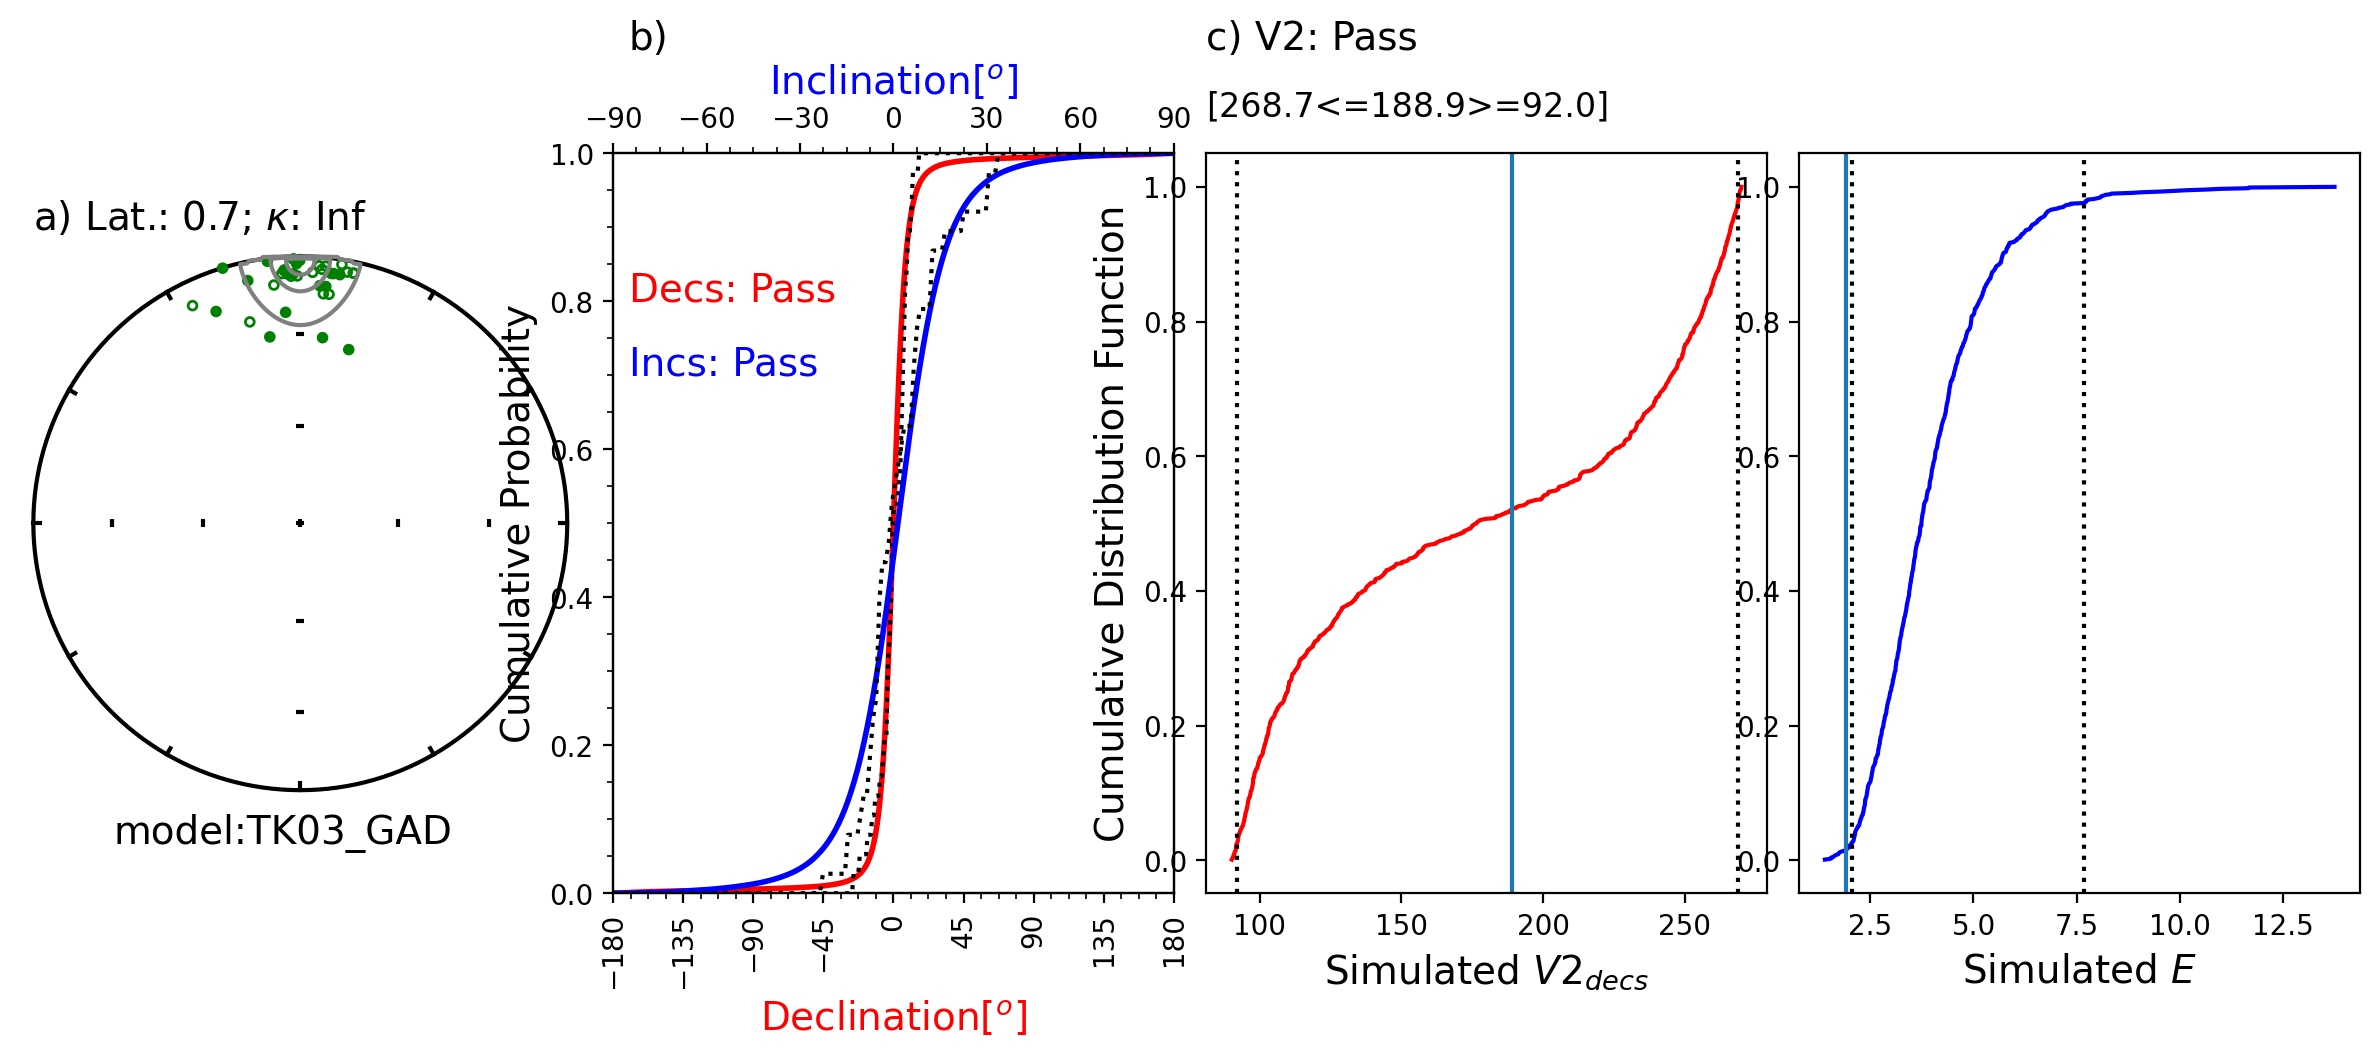

In [8]:
try:
    svei_result = pt.svei_test_vgps(sudbury, study_lon, study_lat, model='TK03_GAD', plot=True)
except TypeError:   # PmagPy plotting bug when elongation falls below the model minimum
    svei_result = pt.svei_test_vgps(sudbury, study_lon, study_lat, model='TK03_GAD', plot=False)
    print('(SVEI elongation plot skipped: E below the TK03.GAD model minimum)')
print(f"paleolatitude = {svei_result['lat']:.1f} deg; elongation E = {svei_result['E']:.2f} "
      f"({'consistent' if svei_result['E_result'] else 'inconsistent'} with TK03.GAD)")

## The Sudbury pole in the context of the Laurentia APWP

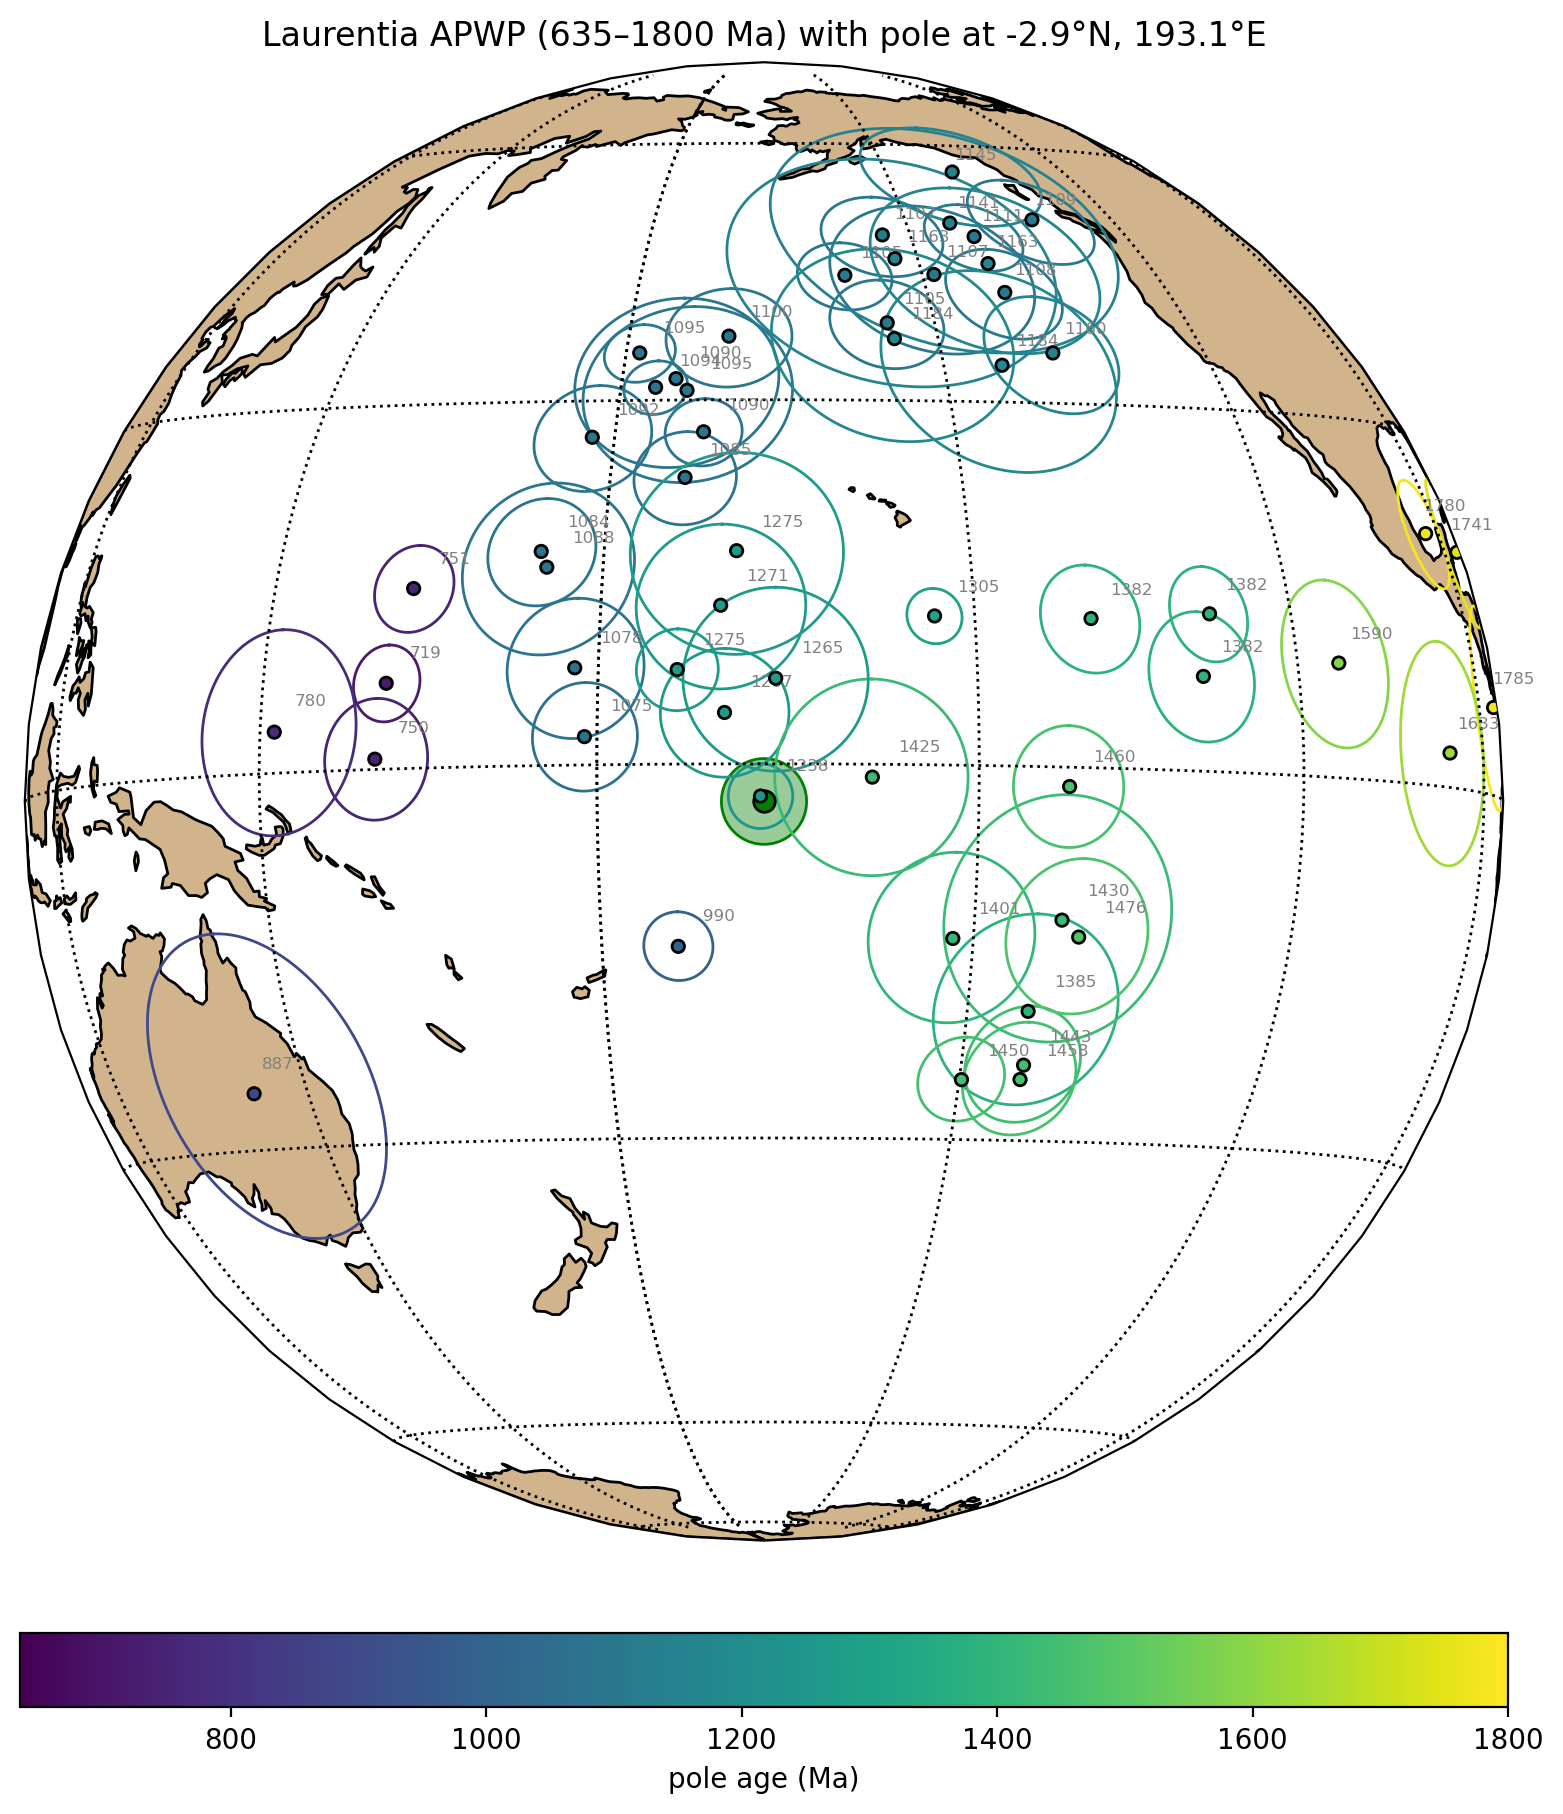

In [9]:
Laurentia_poles = pt.get_Laurentia_poles()
ax = pt.plot_apwp_context(Laurentia_poles, pole_mean['inc'], pole_mean['dec'],
                          pole_mean['alpha95'], age_min=635, age_max=1800,
                          projection='orthographic',
                          central_longitude=pole_mean['dec'],
                          central_latitude=pole_mean['inc'])
plt.show()

## R7: comparison with younger Laurentia poles

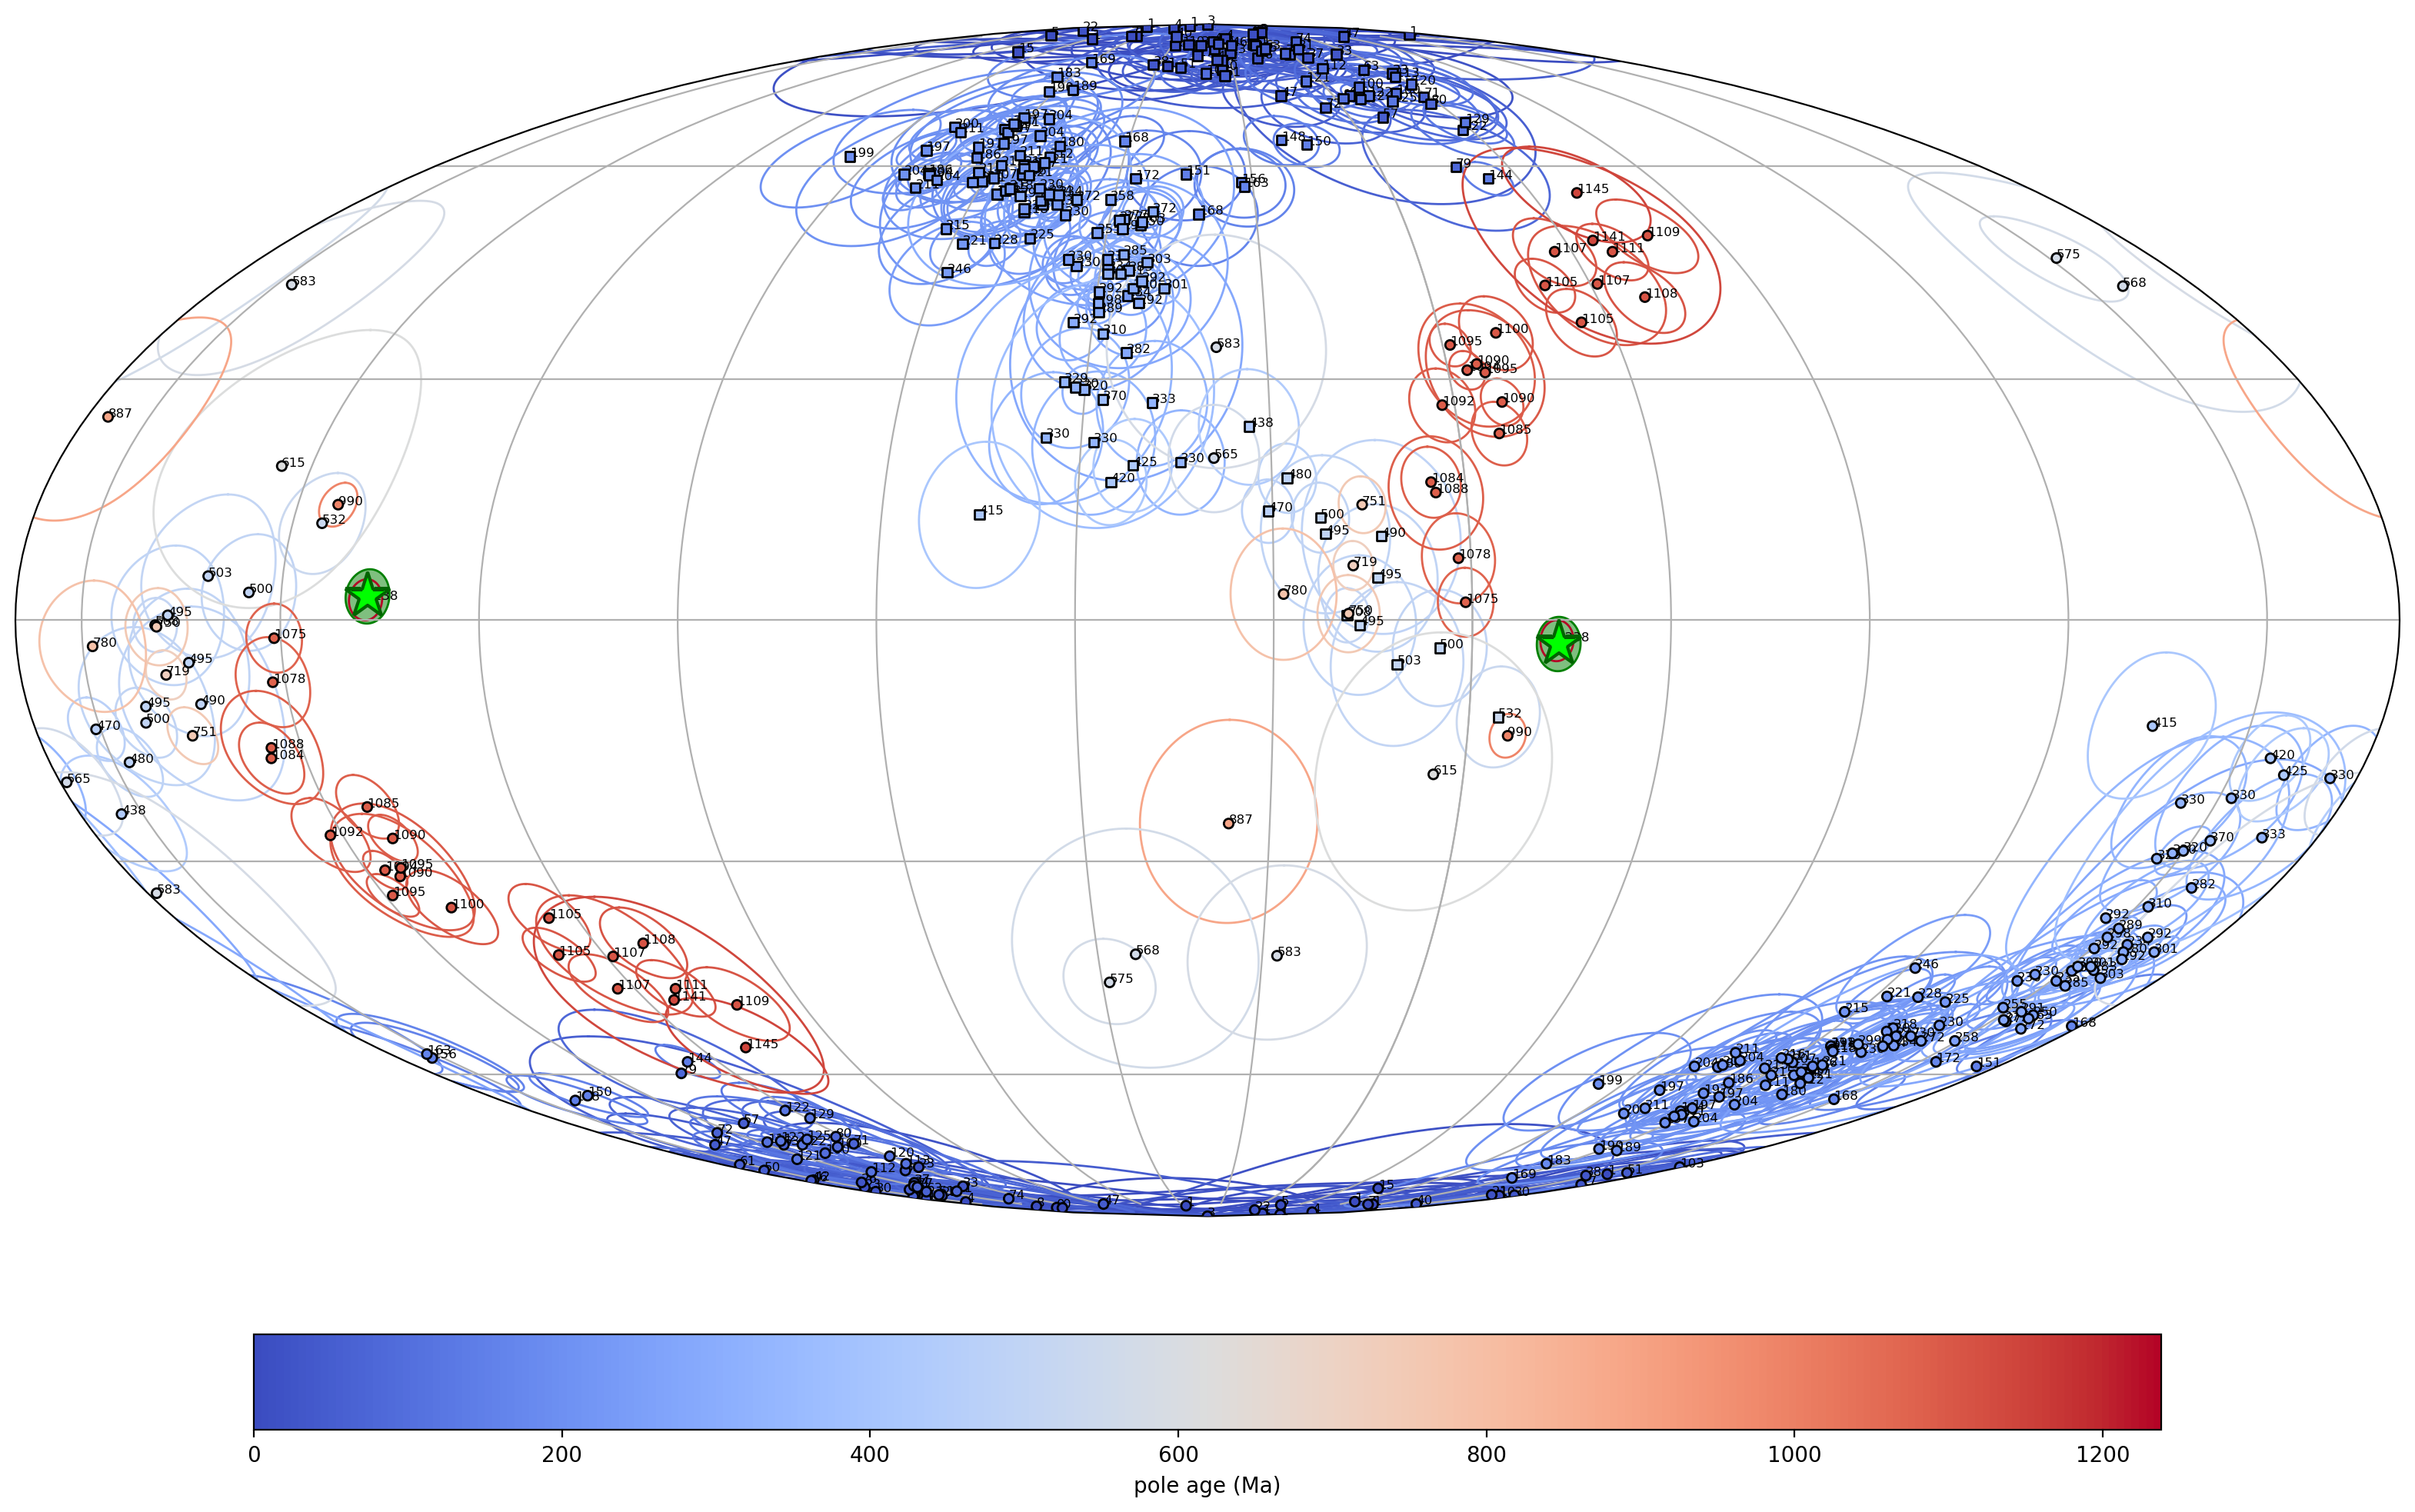

<GeoAxesSubplot:>

In [10]:
Laurentia_stricto_poles = pt.get_Laurentia_stricto_poles()
pt.plot_pole_overlap('Sudbury Dike Swarm', Laurentia_stricto_poles,
                     pt.Torsvik2012_Laurentia,
                     pole_plat=pole_mean['inc'], pole_plon=pole_mean['dec'],
                     pole_A95=pole_mean['alpha95'], pole_age=1238)

## R-score summary (Meert et al., 2020)

| R | Criterion | Score | Justification |
|---|---|---|---|
| 1 | Age within ± 15 Ma | **1** | U-Pb baddeleyite 1238 ± 4 Ma on the Sudbury swarm (Krogh et al., 1987; Fahrig & West, 1986). |
| 2 | Techniques and statistical analysis | **1** | AF (and thermal) demagnetization with stable-endpoint analysis; N = 38 site means, K = 50.4, A95 = 3.3° passes the Deenen et al. (2011) envelope (K within 10-70). This updates the prior compilation R2 = 0, which reflected the artificially high K = 1000 of the combined-result entry. |
| 3 | Magnetic mineralogy characterized | **1** | Remanence carried by magnetite in the olivine diabase, with rock-magnetic (Curie point) characterization (Palmer et al., 1977). |
| 4 | Field tests constrain age of magnetization | **C** | Positive baked-contact test at site 90 against Gowganda argillites, plus the positive baked-contact tests of Sopher (1963) and Schwarz (1977) against Sudbury norite, establish a primary magnetization. |
| 5 | Structural control / tectonic coherence | **1** | Autochthonous Southern Province of the Canadian Shield; vertical dikes require no tilt correction. |
| 6 | Presence of reversals | **0** | The primary Sudbury dike direction is of single polarity. |
| 7 | No resemblance to younger poles | **1** | Distinct from younger Laurentia poles; the ESE-down Grenville-Front overprint (ca. 1000 Ma) is a separate, identified population. |
| | Total | **6/7** | Grade A |

## Nordic workshop summary

The primary Sudbury Dike Swarm pole is recreated at the site level from the 38
dikes carrying the Sudbury dike direction (Palmer et al., 1977). The recreation
(-2.9°N/193.1°E, A95 3.3°) reproduces both Palmer's published pole
(168°W/2.5°S, A95 2.5°) and the prior compilation's combined pole
(-2.5°N/192.8°E) within their mutual confidence limits. R2 is updated from the
prior compilation's 0 to 1 by scoring the paleosecular-variation criterion
directly from the recreated VGPs (K = 50.4, within 10-70, A95 passes Deenen),
the prior 0 having reflected the over-concentrated K = 1000 of the combined entry.

### Primary Sudbury dike pole

| | This study (site VGPs) | Palmer et al. (1977) | Previous Nordic compilation |
|---|---|---|---|
| Component | Primary Sudbury dike direction | Sudbury dikes (this study) | Combined Result |
| N (sites) | 38 | 38 | 52 |
| N (specimens) | 148 | — | 205 |
| Dec (°) | 264.8 | 264.8 | 265.2 |
| Inc (°) | 1.7 | 1.7 | 2.3 |
| k (direction) | 27.5 | 27.5 | 1000.0 |
| α95 (direction, °) | 4.5 | — | 3.5 |
| Pole lat (°N) | -2.9 | -2.9 | -2.5 |
| Pole lon (°E) | 193.1 | 193.1 | 192.8 |
| A95 | 3.3 | 3.3 | 2.5 |
| pole (°) | 51 | 51 | — |
| dp / dm (°) | — | — | 2.5 / 2.5 |


In [11]:
sudbury_summary = pt.make_nordic_summary(
    terrane='Laurentia',
    rockname='Sudbury Dike Swarm',
    sites=sudbury,
    dir_mean=dir_mean,
    pole_mean=pole_mean,
    study_lon=study_lon,
    study_lat=study_lat,
    component_comment='Primary Sudbury dike direction (westerly, shallow); magnetite-carried characteristic remanent magnetization',
    tests='C+ (positive baked-contact test at site 90 vs. Gowganda argillites; Sopher, 1963; Schwarz, 1977 vs. Sudbury norite)',
    gpmdb_number='2175',
    percent_reversed=0,
    demag_code=3,
    R1=1, R2=1, R3=1, R4='C', R5=1, R6=0, R7=1, Grade='A',
    nominal_age=1238, lomagage=1234, himagage=1242,
    REF_method='U-Pb baddeleyite age 1238 +/- 4 Ma on the Sudbury dike swarm (Krogh et al., 1987; Fahrig & West, 1986), superseding the ca. 1250 Ma K-Ar estimate of Palmer et al. (1977).',
    POLE_AUTHORS='Palmer, H. C., Merz, B. A., & Hayatsu, A.',
    YEAR=1977,
    JOURNAL='Canadian Journal of Earth Sciences',
    VOLUME='14',
    VPAGES='1867-1887',
    TITLE='The Sudbury dikes of the Grenville Front region: paleomagnetism, petrochemistry, and K-Ar age studies',
    COMMENT='Primary Sudbury Dike Swarm pole recreated at the site level from the 38 Sudbury-dike-direction dikes of Palmer et al. (1977) (audited MagIC contribution 20644). Recreated -2.9N/193.1E, A95 3.3, N=38; reproduces Palmer published pole (168W/2.5S, A95 2.5) and prior compilation combined pole (-2.5N/192.8E, GPMDB 2175) within mutual A95. Positive baked-contact test (site 90; Sopher 1963; Schwarz 1977). R2 updated 0->1 (recreated K=50.4 within 10-70 passes Deenen; prior 0 reflected the combined-entry K=1000). Single primary polarity (R6=0). Grenville-Front ESE-down overprint (ca. 1000 Ma) shown for context.'
)
pt.save_nordic_summary(sudbury_summary, '1237_Sudbury')
sudbury_summary

,Terrane,ROCKNAME,RESULT#,COMPONENT,TESTS,TILT,SLAT,SLONG,B,N,...,himagage,REF/method,ROCKNAME,POLE AUTHORS,YEAR,JOURNAL,VOLUME,VPAGES,TITLE,Comment
0,Laurentia,Sudbury Dike Swarm,GPMDB:2175,"Primary Sudbury dike direction (westerly, shal...",C+ (positive baked-contact test at site 90 vs....,0,46.3,278.6,38,148,...,1242,U-Pb baddeleyite age 1238 +/- 4 Ma on the Sudb...,Sudbury Dike Swarm,"Palmer, H. C., Merz, B. A., & Hayatsu, A.",1977,Canadian Journal of Earth Sciences,14,1867-1887,The Sudbury dikes of the Grenville Front regio...,Primary Sudbury Dike Swarm pole recreated at t...
